In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pyHockneySolver import solve_open_poisson_hockney

np.random.seed(33)

## Constants & Parameters

In [ ]:
# PHYSICAl CONSTANTS

# M_E = 9.1093837015e-31 # electron mass in kg
M_E = 0.511 # electron mass in MeV/c^2
Q_E_SI = -1.602176634e-19 # electron charge in C
Q_E = -1. # electron charge in e
EPSILON_0 = 5.5263494e13  # vacuum permittivity in in e/(MV*m)
C = 299792458 # speed of light in m/s


# HYPERPARAMETERS

LENGTH_PRIOR = 0.5 # length of prior region to be modeled in m
LENGTH_D = 0.25 # length of drift chamber in m
LENGTH_E = 3.75 # length of electric field chamber in m
LENGTH_POSTERIOR = 2.5 # length of posterior region to be modeled in m

RADIUS_X = 0.1 # width of model space in x direction in m
RADIUS_Y = 0.1 # width of model space in y direction in m


ENERGY_0 = 1e-2 # initial kinetic energy of reference particle in MeV


SIGMA_X = 1e-3 # standard deviation of initial x position in m
SIGMA_Y = 1e-3 # standard deviation of initial y position in m
SIGMA_Z = 0.1 # standard deviation of initial z position in m

SIGMA_PX_BG = 1e-9 # standard deviation of initial x momentum in 1 (betagamma)
SIGMA_PY_BG = 1e-9 # standard deviation of initial y momentum in 1 (betagamma)
SIGMA_PZ_BG = 1e-2 # standard deviation of initial z momentum in 1 (betagamma)


E_Z = -1. # electric field strength in MV/m

# N_P = int(1e4) # number of macro particles
N_PARTICLES = 32*32*32 # number of macro particles
TOTAL_CHARGE_SI = -1e-9 # total bunch charge in C

DELTA_POS = 1e-2  # spacing of z-grid (Fields, Space Charge, etc.) in m
DELTA_T = 2e-11 # time step in s    CFL-Condition: DELTA_T < DELTA_Z / C
T_MAX = 1e-7 # maximum simulation time in s

# Hockney solver parameters
GRID_PADDING = 0.2 # max(RADIUS_X, RADIUS_Y, LENGTH_POSTERIOR, LENGTH_PRIOR) 
GRID_N_XYZ = (12, 12, 256)

# DERIVED QUANTITIES

Z_START = -LENGTH_PRIOR # start of model space
Z_0 = Z_START + LENGTH_PRIOR # initial z position of particles
Z_1 = Z_START + LENGTH_PRIOR + LENGTH_D # z position of end of drift chamber = start of electric field chamber
Z_2 = Z_START + LENGTH_PRIOR + LENGTH_D + LENGTH_E # z position of end of electric field chamber
Z_END = Z_2 + LENGTH_POSTERIOR # end of model space

GAMMA_0 = (ENERGY_0 + M_E) / M_E # initial Lorentz factor of reference particle
BETA_0 = np.sqrt(1 - 1 / GAMMA_0**2) # initial beta of reference particle
PZ_0 = BETA_0 * GAMMA_0 * M_E # initial momentum of reference particle in MeV/c

POSITION_0 = (0., 0., Z_0) # initial position (of reference particle) in m
MOMENTUM_0 = (0., 0., PZ_0) # initial momentum in MeV/c

BG_to_P = lambda bg: bg * M_E # function to transform momentum from betagamma to particle units

POSITION_SIGMA = (SIGMA_X, SIGMA_Y, SIGMA_Z) # in m
MOMENTUM_SIGMA = (BG_to_P(SIGMA_PX_BG), BG_to_P(SIGMA_PY_BG), BG_to_P(SIGMA_PZ_BG)) # in MeV/c


N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI / Q_E_SI) # number of real electrons in the bunch
MACRO_WEIGHT = N_REAL_PARTICLES / N_PARTICLES 

M_MACRO = M_E * MACRO_WEIGHT
Q_MACRO = Q_E * MACRO_WEIGHT

# assert DELTA_T < DELTA_POS / C, "CFL condition violated: DELTA_T must be less than DELTA_Z / C"

## Phyiscs Helper

In [23]:
def p_to_betagamma(p):
    '''
    Transform momentum from particle units [MeV/c] to dimensionless beta*gamma unit [1]
    '''

    return p / M_E

def betagamma_to_p(betagamma):
    '''
    Transform momentum from dimensionless beta*gamma unit [1] to particle units [MeV/c]
    '''

    return betagamma * M_E


## Plotting Helper

In [24]:
AX_NAMES = ['x', 'y', 'z']

X_GRID = np.arange(-RADIUS_X, RADIUS_X + DELTA_POS, DELTA_POS)
Y_GRID = np.arange(-RADIUS_Y, RADIUS_Y + DELTA_POS, DELTA_POS)
Z_GRID = np.arange(Z_START, Z_END + DELTA_POS, DELTA_POS)
N_X, N_Y, N_Z = len(X_GRID), len(Y_GRID), len(Z_GRID)
POSITION_GRID = np.stack(np.meshgrid(X_GRID, Y_GRID, Z_GRID, indexing='ij'), axis=-1)
# E_EXT_GRID = np.zeros_like(POSITION_GRID)
# E_EXT_GRID[:, :, (Z_GRID >= Z_1) & (Z_GRID <= Z_2), :] = E_Z

def PLOT_particles(positions, momenta, title="Particle Distribution"):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for i in range(3):
        axes[i].scatter(positions[:, i], momenta[:, i], alpha=0.5)
        axes[i].set_title(title)
        axes[i].set_xlabel(f'{AX_NAMES[i]} (m)')
        axes[i].set_ylabel(f'p_{AX_NAMES[i]} (MeV/c)')
        axes[i].grid()

def PLOT_particles_3D(positions, title="Particle Distribution"):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], alpha=0.5)
    ax.plot(np.zeros(N_Z), np.zeros(N_Z), Z_GRID, alpha=0.5, color='black', label='z-axis')
    ax.plot(np.zeros(N_Y), Y_GRID, np.full(N_Y, POSITION_0[2]), alpha=0.5, color='red', label='y-axis')
    ax.plot(X_GRID, np.zeros(N_X), np.full(N_X, POSITION_0[2]), alpha=0.5, color='blue', label='x-axis')
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')

    plt.show()

def PLOT_rho_3D(rho_grid, title="Charge Density"):
    # make a 3D plot of the charge density with shape (N_X, N_Y, N_Z) using matplotlib
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    X, Y, Z = POSITION_GRID
    ax.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=rho_grid.flatten(), cmap='viridis', marker='o')
    ax.set_title(title)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    # ax.set_aspect('equal')
    plt.show()

## Solver Helper

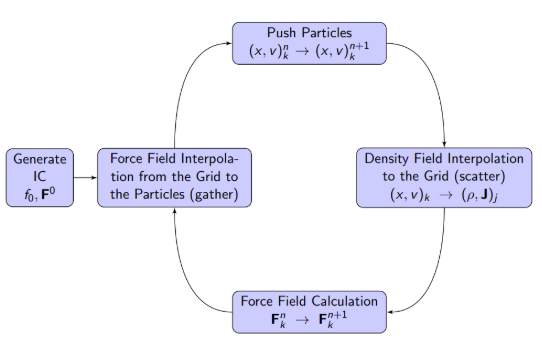
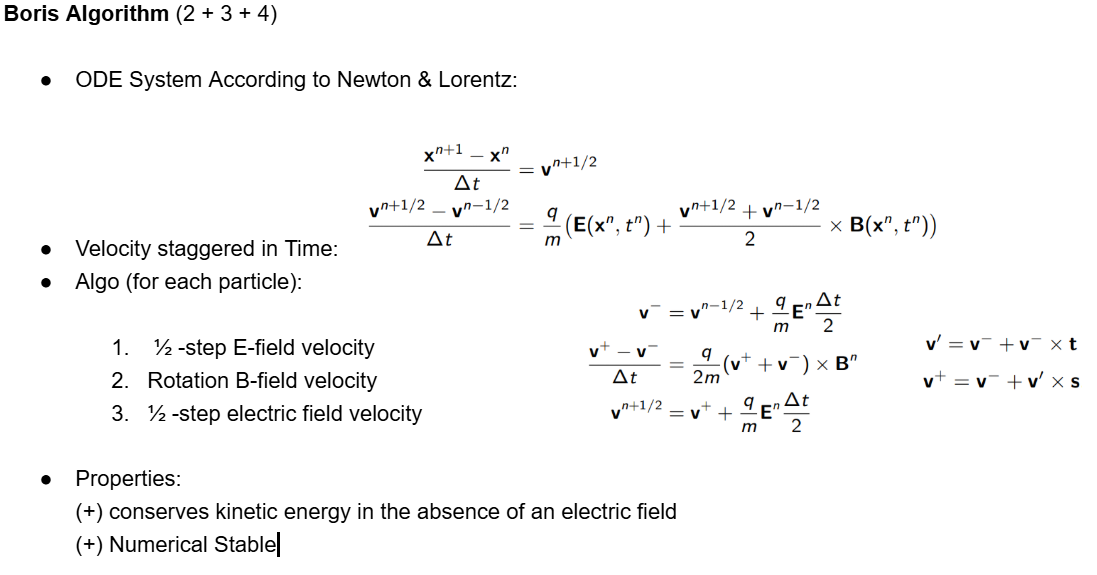
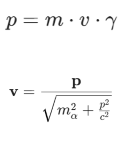
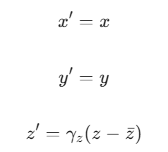
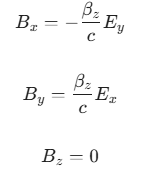
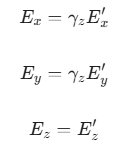

In [25]:
def transform_position_lab_to_rest(position_particles_lab, momentum_particles_lab):
    '''
    Transform particle positions from lab frame to rest frame of reference particle(mean momentum & position)
    '''
    z_mean_lab = np.mean(position_particles_lab[:, 2])
    p_z_mean_lab = np.mean(momentum_particles_lab[:, 2])

    gamma_z = np.sqrt(1.0 + (p_z_mean_lab / M_E)**2)    
    beta_z = p_z_mean_lab / (gamma_z * M_E) # in c

    # Lorentz transformation for positions
    position_particles_rest = np.copy(position_particles_lab)
    position_particles_rest[:, 2] = gamma_z * (position_particles_lab[:, 2] - z_mean_lab) # gamma(z - beta_z*t)

    return position_particles_rest, gamma_z, beta_z

def transform_fields_rest_to_lab(
        E_particles_rest, 
        gamma_z,
        beta_z
    ):
    '''
    Transform E-field from rest fram to E- & B-field in lab frame
    '''
    E_particles_lab = np.zeros_like(E_particles_rest)
    B_particles_lab = np.zeros_like(E_particles_rest)
    
    E_particles_lab[:, 0] = gamma_z * E_particles_rest[:, 0]
    E_particles_lab[:, 1] = gamma_z * E_particles_rest[:, 1]
    E_particles_lab[:, 2] = E_particles_rest[:, 2]
    
    B_particles_lab[:, 0] = - (beta_z / C) * E_particles_lab[:, 1]
    B_particles_lab[:, 1] =   (beta_z / C) * E_particles_lab[:, 0]
    B_particles_lab[:, 2] = 0.0
    
    return E_particles_lab, B_particles_lab

def E_tot_particles(position_particles, E_int_particles):
    '''
    Add external electric field to internal electric field at particle positions
    '''

    E_ext_particles = np.zeros_like(E_int_particles)
    E_ext_particles[ 
        (position_particles[:, 2] >= Z_1) & 
        (position_particles[:, 2] <= Z_2)   
        , :] = np.array([0., 0., E_Z])

    return E_int_particles + E_ext_particles

def gamma_particles(momentum_particles):
    '''
    Calculate relativistic gamma factor from particle momentum

    Returns np.array of shape (N_P,1)
    '''
    p_squared = np.sum(momentum_particles**2, axis=1, keepdims=True)
    gamma = np.sqrt(1. + (p_squared / M_E**2))

    return gamma

def calc_t_and_s(B_particles, gamma):
    '''
    Calculate t and s vectors for Boris push
    '''
    t_factor = (0.5 * Q_E * (C**2) * DELTA_T) / M_E
    t = B_particles * (t_factor / gamma) # t hat die Form (N, 3)
    
    t_squared = np.sum(t**2, axis=1, keepdims=True)
    s = (2.0 * t) / (1.0 + t_squared)

    return t, s

def velocity_particles_SI(momentum_particles):
    '''
    Calculate particle velocity from momentum
    '''
    gamma = gamma_particles(momentum_particles)
    velocity_particles = (momentum_particles / (gamma * M_E)) * C # convert from MeV/c to m/s

    return velocity_particles

def push_particles(position_particles, momentum_stag_particles, E_particles, B_particles):
    '''
    Update particle positions and momenta based on electric field
    '''

    # Using Velocity Verlet & Boris push

    # 1. Half E-field push 
    p_minus = momentum_stag_particles + Q_E * E_particles * (C*DELTA_T)/2
    
    # 2. B-field Rotation
    gamma = gamma_particles(p_minus)
    t, s = calc_t_and_s(B_particles, gamma)
    
    # 2.1 Half Rotation
    p_prime = p_minus + np.cross(p_minus, t)
    
    # 2.2 Half Rotation
    p_plus = p_minus + np.cross(p_prime, s)

    # 3. Half E-field push
    next_momentum_stag_particles = p_plus + Q_E * E_particles * (C*DELTA_T)/2


    next_velocity_stag_particles = velocity_particles_SI(next_momentum_stag_particles)
    next_position_particles = position_particles + next_velocity_stag_particles * DELTA_T

    return next_position_particles, next_momentum_stag_particles


    

## Initialization

In [26]:
position_particles = np.random.normal(POSITION_0, POSITION_SIGMA, (N_PARTICLES, 3))
momentum_particles = np.random.normal(MOMENTUM_0, MOMENTUM_SIGMA, (N_PARTICLES, 3))
position_particles.shape

(32768, 3)

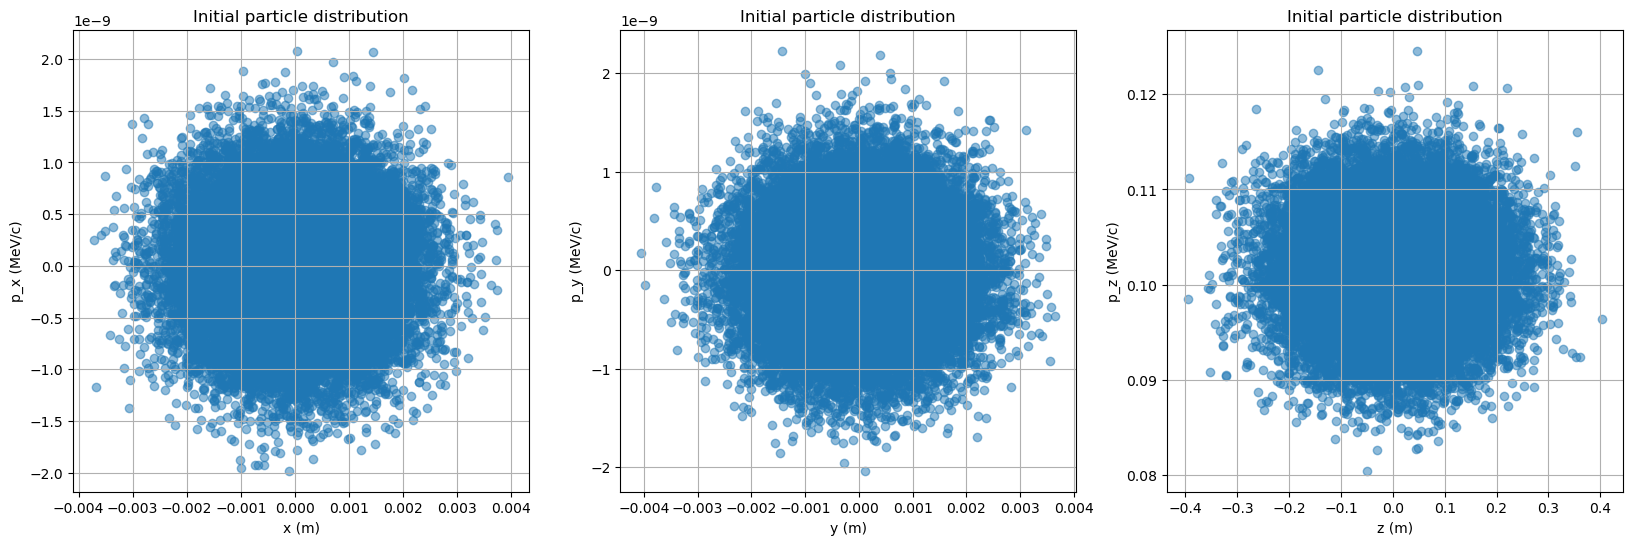

In [27]:
PLOT_particles(position_particles, momentum_particles, 'Initial particle distribution')

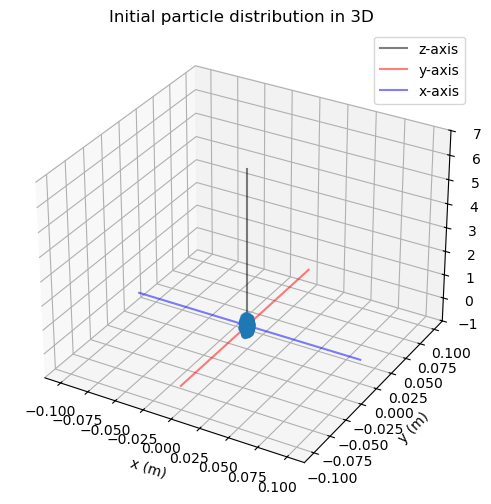

In [28]:
PLOT_particles_3D(position_particles, 'Initial particle distribution in 3D')

## INTEGRATION LOOP

In [29]:
# Initialize staggered Momentum 

position_particles_rest, gamma_z, beta_z = transform_position_lab_to_rest(position_particles, momentum_particles)

E_int_particles_rest = solve_open_poisson_hockney(
    position_particles_rest,
    charge_per_particle= Q_MACRO,
    grid_shape=GRID_N_XYZ,
    padding=GRID_PADDING,
    eps0=EPSILON_0,
)["E_particles"]

E_int_particles, B_particles = transform_fields_rest_to_lab(E_int_particles_rest, gamma_z, beta_z)
E_particles = E_tot_particles(position_particles, E_int_particles)

momentum_stag_particles = momentum_particles - Q_E * E_particles * (C*DELTA_T) / 2 # staggered momentum for Velocity Verlet

[solve_open_poisson_hockney] scatter=10.25 ms, solve+Efield=38.86 ms, gather=11.77 ms, total=67.39 ms


In [30]:
# Main integration loop

nums_particles = [N_PARTICLES]
times = [0.]
position_means = [np.mean(position_particles, axis=0)]
momentum_stag_means = [np.mean(momentum_stag_particles, axis=0)]
position_sigmas = [np.std(position_particles, axis=0)]
momentum_stag_sigmas = [np.std(momentum_stag_particles, axis=0)]


z_mean = position_means[-1][-1]
t = 0.
while z_mean < Z_2 and t < T_MAX:

    position_particles_rest, gamma_z, beta_z = transform_position_lab_to_rest(position_particles, momentum_particles)

    E_int_particles_rest = solve_open_poisson_hockney(
        position_particles_rest,
        charge_per_particle= Q_MACRO,
        grid_shape=GRID_N_XYZ,
        padding=GRID_PADDING,
        eps0=EPSILON_0,
    )["E_particles"]

    E_int_particles, B_particles = transform_fields_rest_to_lab(E_int_particles_rest, gamma_z, beta_z)
    E_particles = E_tot_particles(position_particles, E_int_particles)

    position_particles, momentum_stag_particles = push_particles(
        position_particles, 
        momentum_stag_particles, 
        E_particles, 
        B_particles
    )

    # Handle lost particles
    lower_bounds = np.array([-RADIUS_X, -RADIUS_Y, Z_START])
    upper_bounds = np.array([RADIUS_X, RADIUS_Y, Z_END])
    valid_mask = np.all((position_particles >= lower_bounds) & (position_particles < upper_bounds), axis=1)
    position_particles = position_particles[valid_mask]
    momentum_stag_particles = momentum_stag_particles[valid_mask]
    current_num_particles = len(position_particles)


    times.append(t)
    position_means.append(np.mean(position_particles, axis=0))
    momentum_stag_means.append(np.mean(momentum_stag_particles, axis=0))
    position_sigmas.append(np.std(position_particles, axis=0))
    momentum_stag_sigmas.append(np.std(momentum_stag_particles, axis=0))


    nums_particles.append(current_num_particles)
    z_mean = position_means[-1][-1]
    t += DELTA_T 


[solve_open_poisson_hockney] scatter=6.52 ms, solve+Efield=21.86 ms, gather=12.26 ms, total=41.87 ms
[solve_open_poisson_hockney] scatter=4.95 ms, solve+Efield=21.06 ms, gather=10.93 ms, total=38.16 ms
[solve_open_poisson_hockney] scatter=5.19 ms, solve+Efield=21.94 ms, gather=11.69 ms, total=40.04 ms
[solve_open_poisson_hockney] scatter=5.07 ms, solve+Efield=24.89 ms, gather=10.63 ms, total=41.84 ms
[solve_open_poisson_hockney] scatter=6.90 ms, solve+Efield=25.98 ms, gather=14.30 ms, total=48.38 ms
[solve_open_poisson_hockney] scatter=5.75 ms, solve+Efield=24.36 ms, gather=13.07 ms, total=44.59 ms
[solve_open_poisson_hockney] scatter=6.34 ms, solve+Efield=22.53 ms, gather=13.07 ms, total=43.14 ms
[solve_open_poisson_hockney] scatter=5.70 ms, solve+Efield=26.83 ms, gather=14.05 ms, total=47.85 ms
[solve_open_poisson_hockney] scatter=5.49 ms, solve+Efield=23.97 ms, gather=13.07 ms, total=43.78 ms
[solve_open_poisson_hockney] scatter=5.51 ms, solve+Efield=22.59 ms, gather=12.30 ms, total

## PLOTTING

In [31]:
times = np.array(times)
times_stag = times - DELTA_T / 2
position_means = np.array(position_means)
momentum_stag_means = np.array(momentum_stag_means)
position_sigmas = np.array(position_sigmas)
momentum_stag_sigmas = np.array(momentum_stag_sigmas)

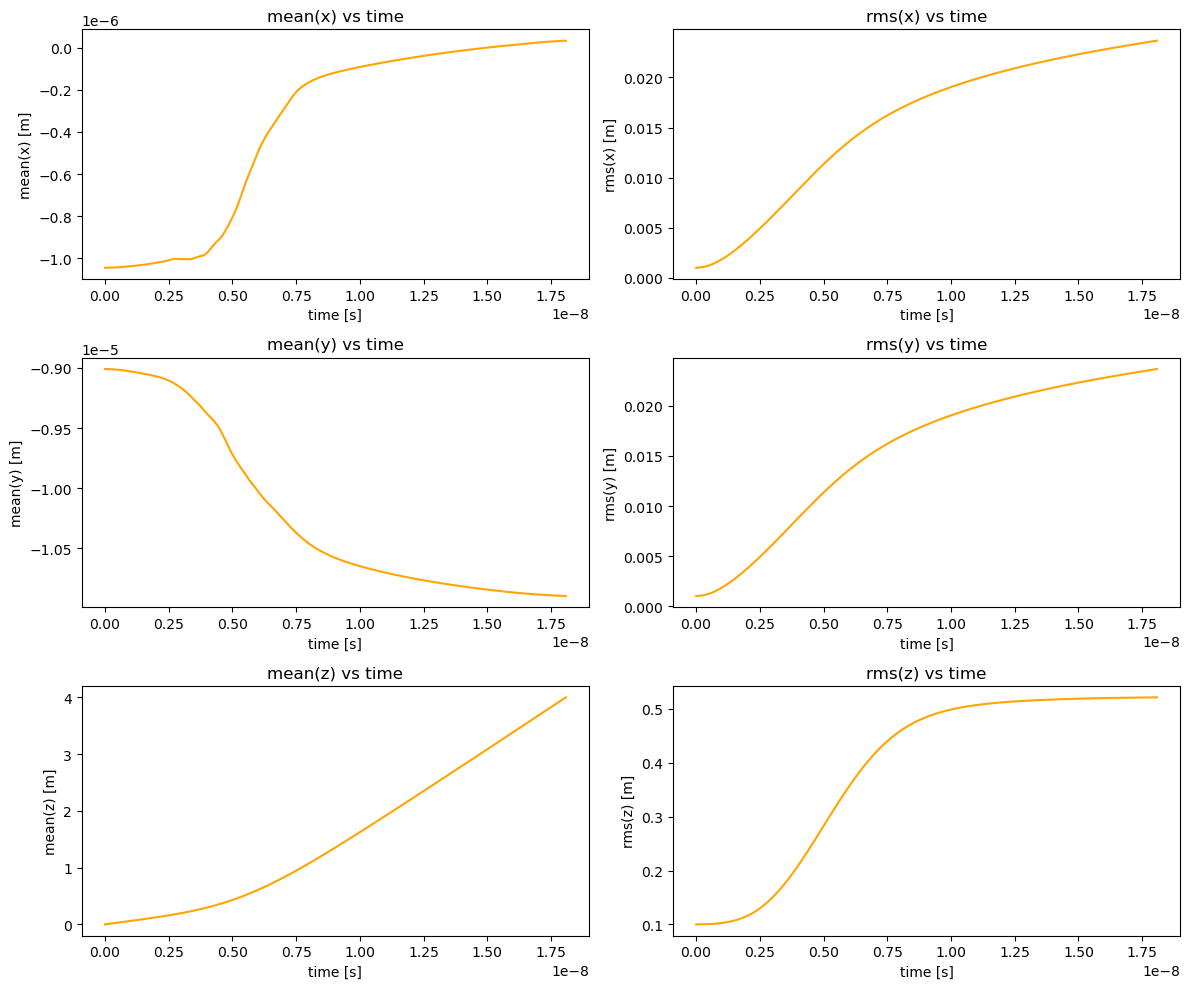

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i in range(3):
    axes[i, 0].plot(times, position_means[:, i], color='orange')
    axes[i, 0].set_xlabel('time [s]')
    axes[i, 0].set_ylabel(f'mean({AX_NAMES[i]}) [m]')
    axes[i, 0].set_title(f'mean({AX_NAMES[i]}) vs time')

    axes[i, 1].plot(times, position_sigmas[:, i], color='orange')
    axes[i, 1].set_xlabel('time [s]')
    axes[i, 1].set_ylabel(f'rms({AX_NAMES[i]}) [m]')
    axes[i, 1].set_title(f'rms({AX_NAMES[i]}) vs time')


fig.tight_layout()
plt.show()

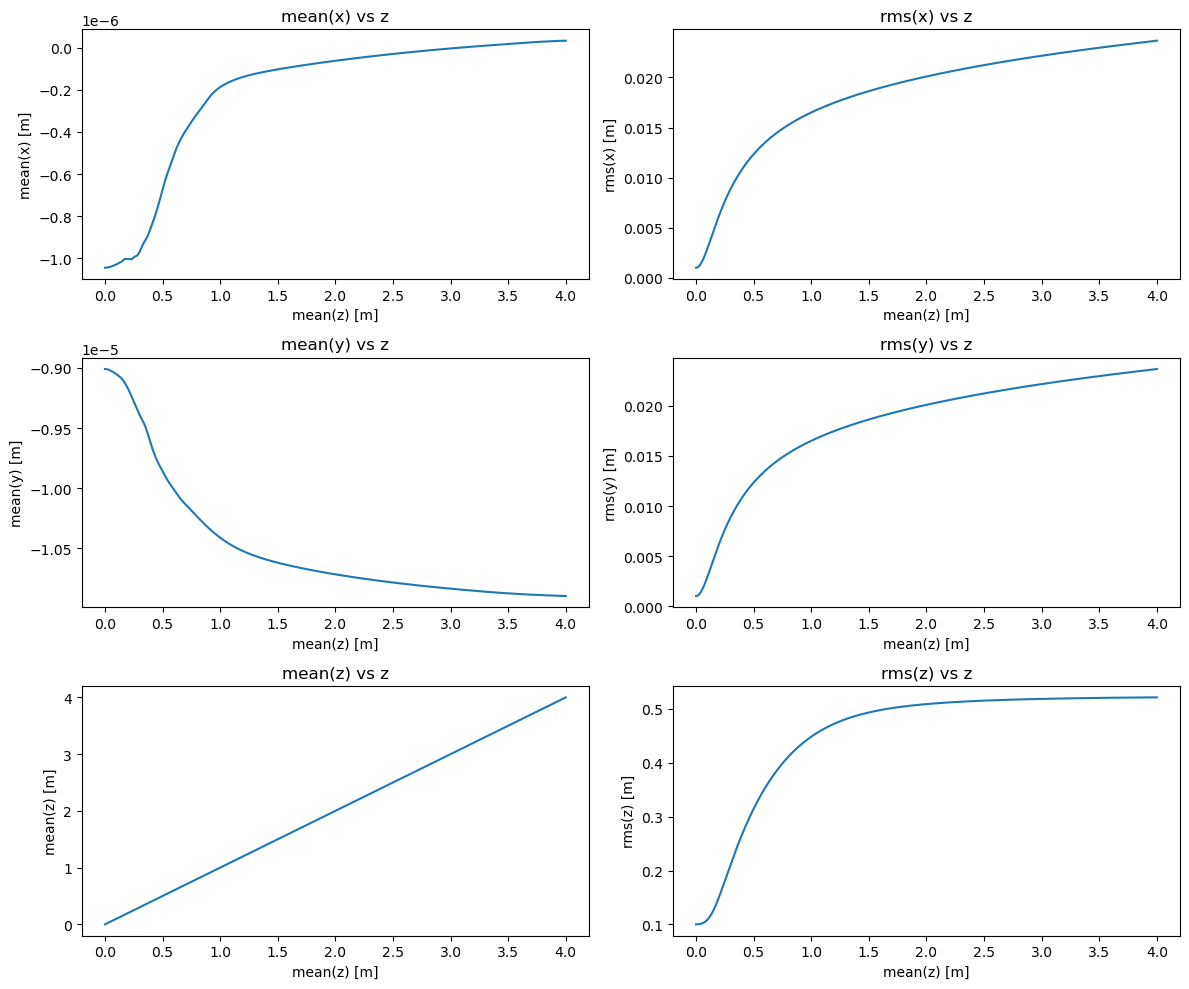

In [33]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i in range(3):
    axes[i, 0].plot(position_means[:, 2], position_means[:, i])
    axes[i, 0].set_xlabel('mean(z) [m]')
    axes[i, 0].set_ylabel(f'mean({AX_NAMES[i]}) [m]')
    axes[i, 0].set_title(f'mean({AX_NAMES[i]}) vs z')

    axes[i, 1].plot(position_means[:, 2], position_sigmas[:, i])
    axes[i, 1].set_xlabel('mean(z) [m]')
    axes[i, 1].set_ylabel(f'rms({AX_NAMES[i]}) [m]')
    axes[i, 1].set_title(f'rms({AX_NAMES[i]}) vs z')


fig.tight_layout()
plt.show()

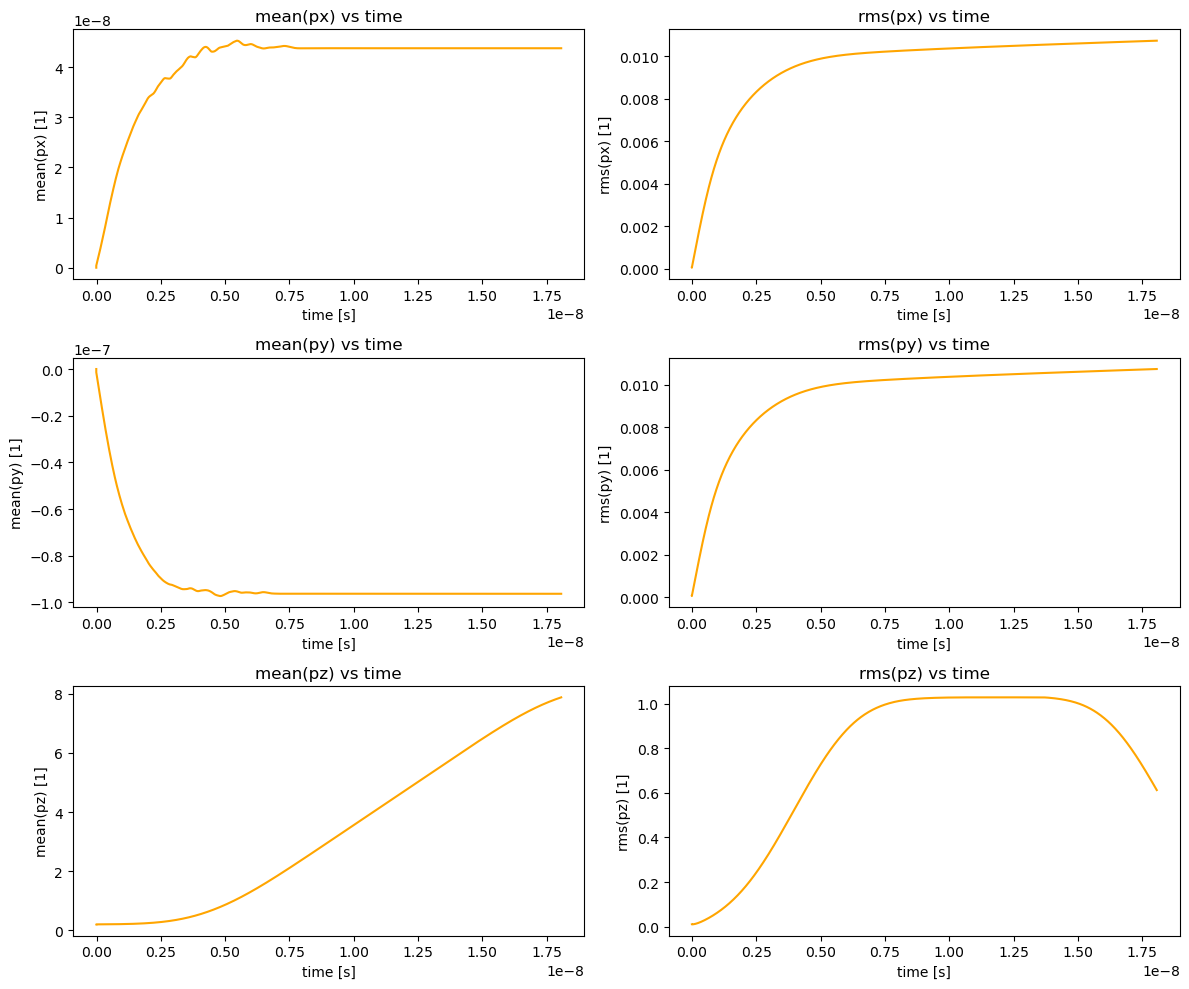

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i in range(3):
    axes[i, 0].plot(times_stag, p_to_betagamma(momentum_stag_means[:, i]), color='orange')
    axes[i, 0].set_xlabel('time [s]')
    axes[i, 0].set_ylabel(f'mean(p{AX_NAMES[i]}) [1]')
    axes[i, 0].set_title(f'mean(p{AX_NAMES[i]}) vs time')

    axes[i, 1].plot(times_stag, p_to_betagamma(momentum_stag_sigmas[:, i]), color='orange')
    axes[i, 1].set_xlabel('time [s]')
    axes[i, 1].set_ylabel(f'rms(p{AX_NAMES[i]}) [1]')
    axes[i, 1].set_title(f'rms(p{AX_NAMES[i]}) vs time')

fig.tight_layout()
plt.show()

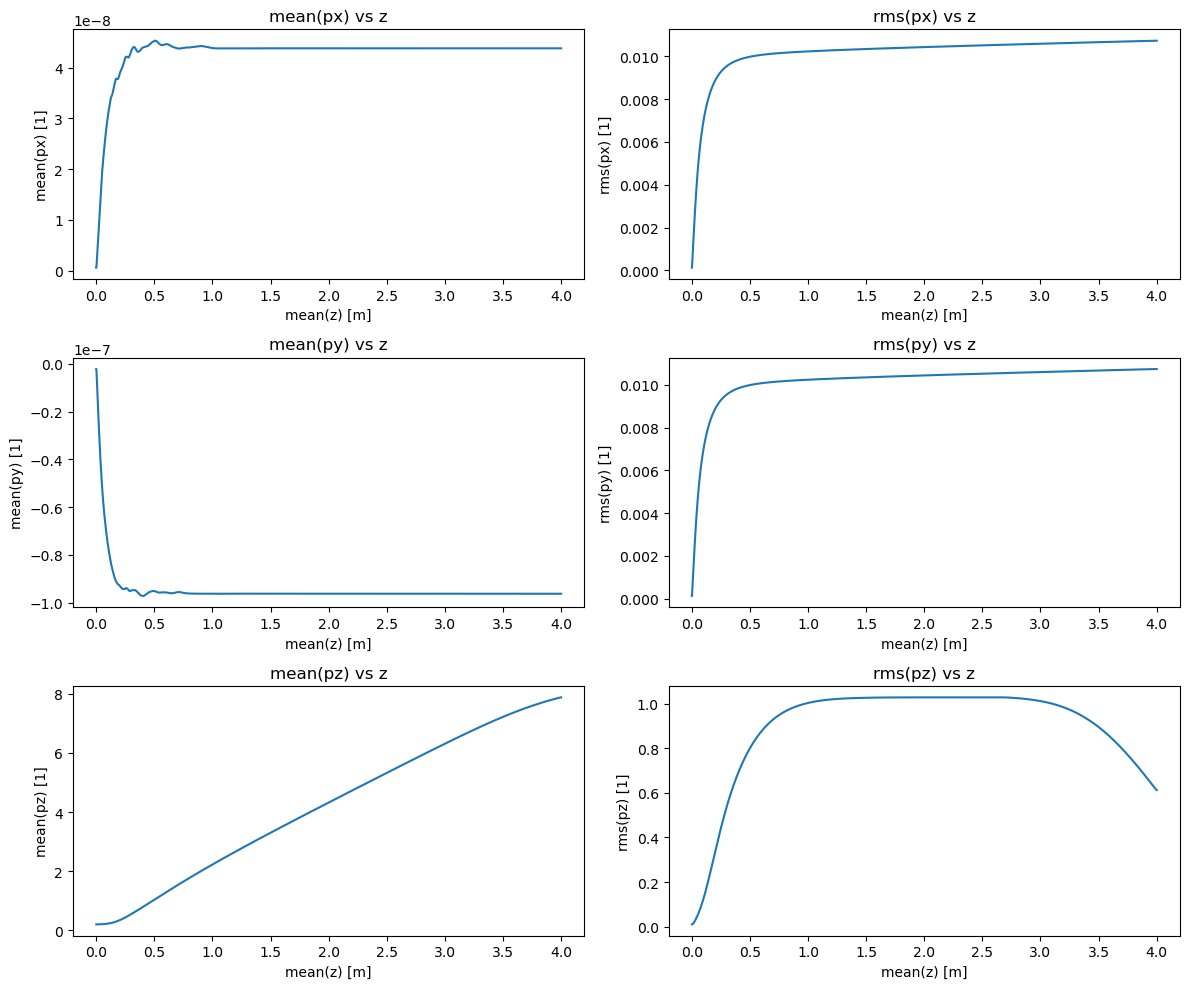

In [35]:
momentum_means_interp = np.zeros_like(momentum_stag_means)
momentum_sigmas_interp = np.zeros_like(momentum_stag_sigmas)
for i in range(3):
    momentum_means_interp[:, i] = np.interp(times, times_stag, momentum_stag_means[:, i])
    momentum_sigmas_interp[:, i] = np.interp(times, times_stag, momentum_stag_sigmas[:, i])


fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i in range(3):
    axes[i, 0].plot(position_means[:, 2], p_to_betagamma(momentum_means_interp[:, i]))
    axes[i, 0].set_xlabel('mean(z) [m]')
    axes[i, 0].set_ylabel(f'mean(p{AX_NAMES[i]}) [1]')
    axes[i, 0].set_title(f'mean(p{AX_NAMES[i]}) vs z')

    axes[i, 1].plot(position_means[:, 2], p_to_betagamma(momentum_sigmas_interp[:, i]))
    axes[i, 1].set_xlabel('mean(z) [m]')
    axes[i, 1].set_ylabel(f'rms(p{AX_NAMES[i]}) [1]')
    axes[i, 1].set_title(f'rms(p{AX_NAMES[i]}) vs z')

fig.tight_layout()
plt.show()

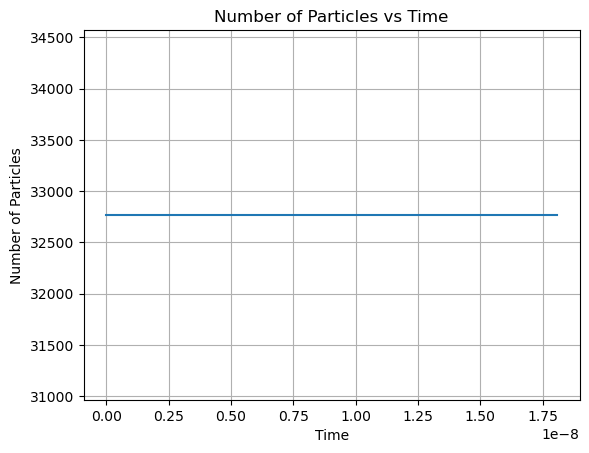

In [36]:
plt.plot(times, nums_particles)
plt.xlabel('Time')
plt.ylabel('Number of Particles')
plt.title('Number of Particles vs Time')
plt.grid()

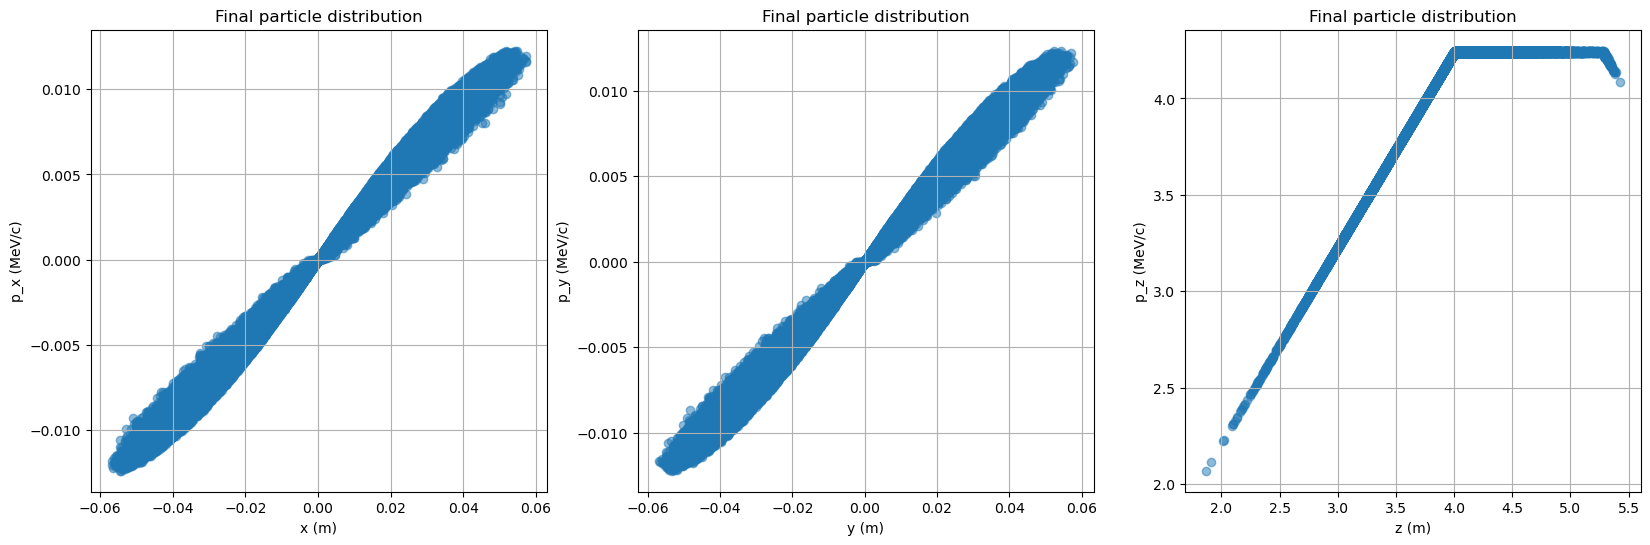

In [37]:
PLOT_particles(position_particles, momentum_stag_particles, 'Final particle distribution')

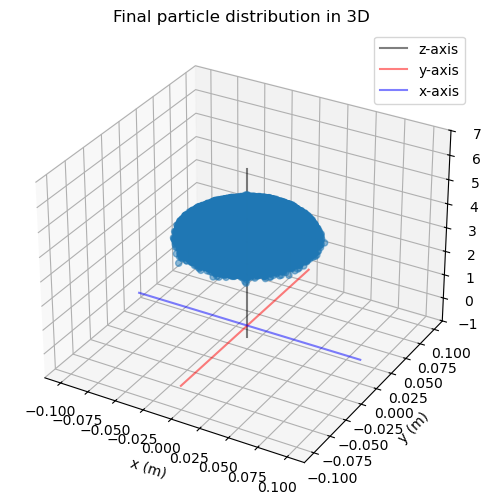

In [38]:
PLOT_particles_3D(position_particles, 'Final particle distribution in 3D')